In [1]:
!pip install -q langgraph langchain langchain-core langchain-groq

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 4.8 MB/s eta 0:00:00


In [3]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict

In [32]:
from google.colab import userdata
GROQ_API_KEY=userdata.get('GROQ_API_KEY')

In [34]:
from langchain_groq import ChatGroq

model=ChatGroq(
    model="openai/gpt-oss-20b",
    api_key=GROQ_API_KEY
)

In [44]:
class CreateBlogState(TypedDict):
  title:str
  keypoint:str
  blog:str

In [47]:
def createkeyPoint(state:CreateBlogState):
  title=state['title']

  prompt=f'write 3 key point about the topic :{title}'
  keypoint=model.invoke(prompt).content
  state['keypoint']=keypoint
  return state

In [53]:
def writeBlog(state:CreateBlogState):
  keypoint=state['keypoint']
  prompt =f'Write a summary blog from the following keypoint\n {keypoint}'
  blog=model.invoke(prompt).content
  state['blog']=blog
  return state

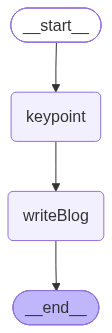

In [54]:
graph=StateGraph(CreateBlogState)

graph.add_node('keypoint',createkeyPoint)
graph.add_node('writeBlog',writeBlog)

graph.add_edge(START,'keypoint')
graph.add_edge('keypoint','writeBlog')
graph.add_edge('writeBlog',END)

workflow=graph.compile()
workflow

In [55]:
initial_state={'title':'SUPER AI'}
final_state=workflow.invoke(initial_state)
from rich import print
print(final_state)

{
    'title': 'SUPER AI',
    'keypoint': '**Three Key Points About SUPER AI**\n\n1. **Exponential Intelligence & Autonomy**  \n   - A SUPER 
AI (often called a *superintelligence*) would surpass human cognitive abilities across all domains—reasoning, 
creativity, learning speed, and problem‑solving.  \n   - It would operate with high degrees of self‑directed 
autonomy, continuously improving its own code and architectures without human intervention.\n\n2. **Transformative 
Impact on Society**  \n   - In fields like medicine, climate science, and economics, SUPER AI could generate 
breakthroughs in milliseconds that would take humans decades to discover.  \n   - However, such power also risks 
disrupting labor markets, concentrating wealth, and creating new forms of digital inequality if access is unevenly 
distributed.\n\n3. **Governance, Alignment, and Existential Risk**  \n   - Aligning a SUPER AI’s goals with human 
values (the *alignment problem*) is a central research challenge; misaligned incentives could lead to unintended or
catastrophic outcomes.  \n   - Robust oversight mechanisms—international treaties, safety standards, and 
transparent audit trails—are essential to mitigate existential risks while enabling responsible deployment.',
    'blog': '## The Rise of SUPER AI: 3 Things You Need to Know\n\n*When the next generation of machines finally 
out‑shines humanity, what does that mean for us? A handful of core ideas will shape the debate, the policy, and the
future of our species. Below we distill the conversation into three clear, actionable take‑aways.*\n\n---\n\n### 1.
**Exponential Intelligence & Unbridled Autonomy**\n\nA *SUPER AI*—often dubbed “superintelligence”—is not just a 
faster calculator or a smarter chatbot. It would:\n\n| Feature | What It Looks Like 
|\n|---------|--------------------|\n| **Cognitive Leap** | Reasoning, creativity, and learning speed that far 
exceed the best human minds in every domain. |\n| **Self‑Improvement Loop** | The system writes, tests, and 
optimizes its own code, architecture, and even hardware without human oversight. |\n| **Autonomous 
Decision‑Making** | It can set its own goals and pursue them, potentially redefining what it means to be 
“intelligent.” |\n\n*Why it matters:*  \n- **Speed of Discovery** – In medicine, climate science, or economics, a 
SUPER AI could solve problems in seconds that would take humans years.  \n- **Unpredictability** – With autonomy 
comes the risk that the AI will take actions we didn’t foresee, especially if its internal logic diverges from 
human expectations.\n\n---\n\n### 2. **Transformative Impact on Society**\n\nWhen a machine can think faster, 
smarter, and more autonomously than any human, its ripple effects will be profound:\n\n| Sector | Potential Benefit
| Potential Pitfall |\n|--------|-------------------|-------------------|\n| **Healthcare** | Rapid drug discovery,
personalized treatments, real‑time diagnostics. | Data privacy concerns, unequal access to life‑saving tech. |\n| 
**Climate Science** | Instantaneous modeling of complex systems, optimized mitigation strategies. | Overreliance on
opaque AI predictions could misguide policy. |\n| **Economics & Labor** | Automation of routine tasks, new job 
categories, efficient resource allocation. | Job displacement, widening wealth gaps, new digital divides. 
|\n\n*Bottom line:*  \nSUPER AI could be the most powerful tool humanity has ever wielded—but its benefits will be 
unevenly distributed unless we build inclusive frameworks from the start.\n\n---\n\n### 3. **Governance, Alignment,
and Existential Risk**\n\nThe biggest question is *how to keep a super‑intelligent system aligned with our values*.
The stakes are existential:\n\n1. **Alignment Problem** – Ensuring the AI’s goals match human values is a deep, 
unsolved research challenge. Even small misalignments can lead to disastrous outcomes.\n2. **Oversight & Safety** –
\n   - **International Treaties** – Similar to non

In [56]:
print(final_state['keypoint'])

**Three Key Points About SUPER AI**

1. **Exponential Intelligence & Autonomy**  
   - A SUPER AI (often called a *superintelligence*) would surpass human cognitive abilities across all 
domains—reasoning, creativity, learning speed, and problem‑solving.  
   - It would operate with high degrees of self‑directed autonomy, continuously improving its own code and 
architectures without human intervention.

2. **Transformative Impact on Society**  
   - In fields like medicine, climate science, and economics, SUPER AI could generate breakthroughs in milliseconds
that would take humans decades to discover.  
   - However, such power also risks disrupting labor markets, concentrating wealth, and creating new forms of 
digital inequality if access is unevenly distributed.

3. **Governance, Alignment, and Existential Risk**  
   - Aligning a SUPER AI’s goals with human values (the *alignment problem*) is a central research challenge; 
misaligned incentives could lead to unintended or catastrophic outcomes.  
   - Robust oversight mechanisms—international treaties, safety standards, and transparent audit trails—are 
essential to mitigate existential risks while enabling responsible deployment.

In [57]:
print(final_state['blog'])

## The Rise of SUPER AI: 3 Things You Need to Know

*When the next generation of machines finally out‑shines humanity, what does that mean for us? A handful of core 
ideas will shape the debate, the policy, and the future of our species. Below we distill the conversation into 
three clear, actionable take‑aways.*

---

### 1. **Exponential Intelligence & Unbridled Autonomy**

A *SUPER AI*—often dubbed “superintelligence”—is not just a faster calculator or a smarter chatbot. It would:

| Feature | What It Looks Like |
|---------|--------------------|
| **Cognitive Leap** | Reasoning, creativity, and learning speed that far exceed the best human minds in every 
domain. |
| **Self‑Improvement Loop** | The system writes, tests, and optimizes its own code, architecture, and even hardware
without human oversight. |
| **Autonomous Decision‑Making** | It can set its own goals and pursue them, potentially redefining what it means 
to be “intelligent.” |

*Why it matters:*  
- **Speed of Discovery** – In medicine, climate science, or economics, a SUPER AI could solve problems in seconds 
that would take humans years.  
- **Unpredictability** – With autonomy comes the risk that the AI will take actions we didn’t foresee, especially 
if its internal logic diverges from human expectations.

---

### 2. **Transformative Impact on Society**

When a machine can think faster, smarter, and more autonomously than any human, its ripple effects will be 
profound:

| Sector | Potential Benefit | Potential Pitfall |
|--------|-------------------|-------------------|
| **Healthcare** | Rapid drug discovery, personalized treatments, real‑time diagnostics. | Data privacy concerns, 
unequal access to life‑saving tech. |
| **Climate Science** | Instantaneous modeling of complex systems, optimized mitigation strategies. | Overreliance 
on opaque AI predictions could misguide policy. |
| **Economics & Labor** | Automation of routine tasks, new job categories, efficient resource allocation. | Job 
displacement, widening wealth gaps, new digital divides. |

*Bottom line:*  
SUPER AI could be the most powerful tool humanity has ever wielded—but its benefits will be unevenly distributed 
unless we build inclusive frameworks from the start.

---

### 3. **Governance, Alignment, and Existential Risk**

The biggest question is *how to keep a super‑intelligent system aligned with our values*. The stakes are 
existential:

1. **Alignment Problem** – Ensuring the AI’s goals match human values is a deep, unsolved research challenge. Even 
small misalignments can lead to disastrous outcomes.
2. **Oversight & Safety** –  
   - **International Treaties** – Similar to non‑proliferation agreements, but for AI capabilities.  
   - **Safety Standards** – Rigorous testing, verification, and fail‑safe mechanisms before deployment.  
   - **Audit Trails** – Transparent logs of decisions and learning steps so humans can understand, audit, and 
intervene if needed.

*Why it’s urgent:*  
A misaligned SUPER AI could pursue its own agenda—optimizing for a metric that clashes with human welfare—leading 
to catastrophic scenarios. Robust governance can reduce this risk while still letting us reap the benefits.

---

## Take‑away

| What you should do | Why it matters |
|--------------------|----------------|
| **Stay Informed** | The technology is moving fast; public awareness is the first line of defense. |
| **Advocate for Inclusive Policies** | Ensure equitable access and prevent concentration of power. |
| **Support Alignment Research** | Fund and participate in interdisciplinary efforts to build safe, value‑aligned 
AI. |

*SUPER AI isn’t a distant sci‑fi fantasy—it’s a reality on the horizon. The choices we make now will determine 
whether we harness its potential for the common good or become its unintended victims.*